# SBM Network Generation & Embedding Playground
**Goal:** Generate networks using SBM and its variants, visualize them, and apply embedding algorithms (ASE, LSE, Node2Vec).

## Contents
1. Install & Imports
2. Basic SBM — generate & visualize
3. Degree-Corrected SBM (DCSBM)
4. Mixed Membership SBM (MMSBM)
5. Adjacency Spectral Embedding (ASE)
6. Laplacian Spectral Embedding (LSE)
7. Node2Vec
8. Compare all embeddings side by side

---
## 1. Install & Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import pandas as pd

from graspologic.simulations import sbm
from graspologic.plot import heatmap, pairplot
from graspologic.embed import AdjacencySpectralEmbed, LaplacianSpectralEmbed
from graspologic.embed import node2vec_embed
from graspologic.utils import pass_to_ranks

from umap import UMAP

sns.set_context('talk')
np.random.seed(42)

print('All imports successful!')

c:\Users\ADMIN\AppData\Local\Programs\Python\Python39\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


All imports successful!


---
## 2. Basic SBM — Generate & Visualize

**Intuition:** Nodes belong to communities (blocks). Nodes in the same community connect with high probability. Nodes in different communities connect with low probability.

The key parameters are:
- `n` — number of nodes per community
- `B` — the block probability matrix (K x K), where B[i][j] = probability of edge between community i and community j

In [2]:
# --- Basic SBM with 3 communities ---

# Number of nodes per community
n = [50, 50, 50]  # 3 communities, 50 nodes each

# Block probability matrix
# High prob on diagonal (within community), low prob off diagonal (between communities)
B = np.array([
    [0.7, 0.05, 0.05],   # community 0 connects strongly within itself
    [0.05, 0.7, 0.05],   # community 1 connects strongly within itself
    [0.05, 0.05, 0.7],   # community 2 connects strongly within itself
])

# Generate the adjacency matrix and labels
A_sbm, labels_sbm = sbm(n, B, return_labels=True)

print(f'Adjacency matrix shape: {A_sbm.shape}')
print(f'Labels (community assignments): {np.unique(labels_sbm, return_counts=True)}')

Adjacency matrix shape: (150, 150)
Labels (community assignments): (array([0, 1, 2], dtype=int64), array([50, 50, 50], dtype=int64))


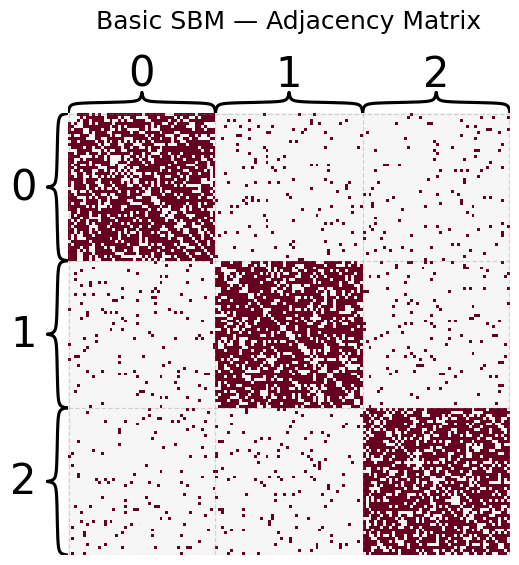

In [3]:
# Visualize the adjacency matrix as a heatmap
# You should see 3 clear dark blocks on the diagonal = 3 communities!
fig, ax = plt.subplots(1, 1, figsize=(7, 6))
heatmap(
    A_sbm,
    inner_hier_labels=labels_sbm,
    title='Basic SBM — Adjacency Matrix',
    ax=ax,
    cbar=False
)
plt.tight_layout()
plt.show()

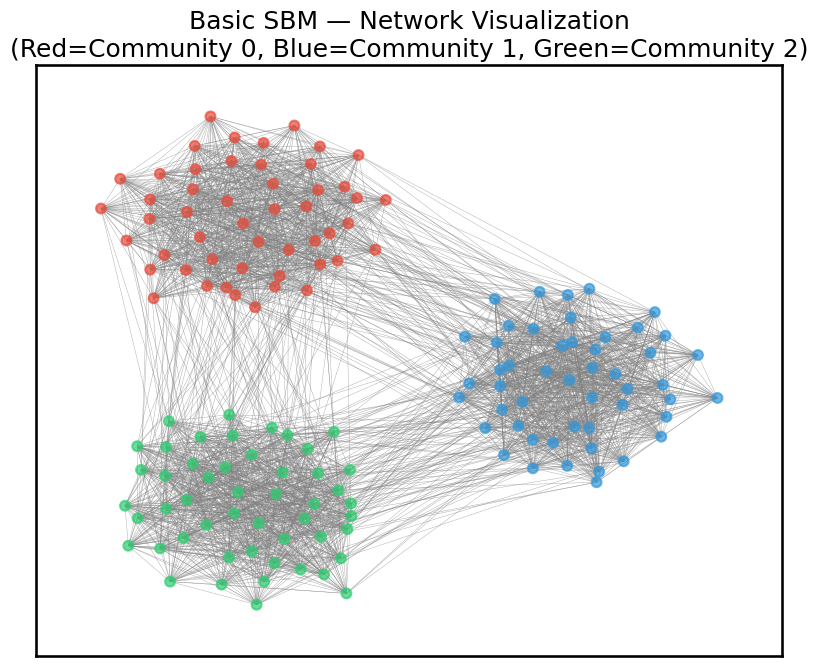

In [4]:
# Also visualize as a network graph using networkx
G_sbm = nx.from_numpy_array(A_sbm)

# Assign community colors
color_map = ['#e74c3c', '#3498db', '#2ecc71']  # red, blue, green
node_colors = [color_map[labels_sbm[node]] for node in G_sbm.nodes()]

fig, ax = plt.subplots(1, 1, figsize=(8, 7))
pos = nx.spring_layout(G_sbm, seed=42)
nx.draw_networkx(
    G_sbm, pos=pos,
    node_color=node_colors,
    node_size=50,
    with_labels=False,
    edge_color='gray',
    alpha=0.7,
    width=0.3,
    ax=ax
)
ax.set_title('Basic SBM — Network Visualization\n(Red=Community 0, Blue=Community 1, Green=Community 2)')
plt.tight_layout()
plt.show()

---
## 3. Degree-Corrected SBM (DCSBM)

**Intuition:** Real networks have hubs — some nodes have way more connections than others, even within the same community. Basic SBM can't capture this because all nodes in a block have the same expected degree.

DCSBM adds a **per-node degree parameter** $\theta_i$ — some nodes are naturally more 'popular' than others.

$$P_{ij} = \theta_i \theta_j B_{\tau_i \tau_j}$$

We simulate this by generating an SBM and then manually rewiring to create degree heterogeneity.

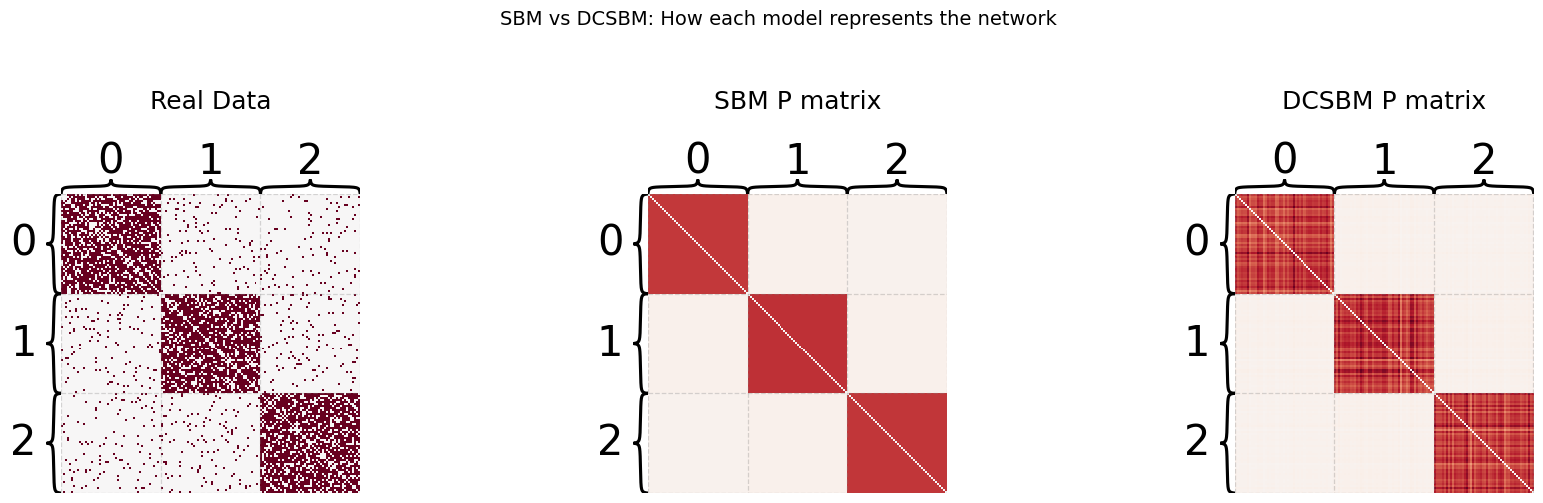

Notice: SBM gives uniform blocks, DCSBM gives smoother gradients within blocks


In [5]:
# Simulate DCSBM manually using graspologic's sbm with degree_directed parameter
# We'll use the DCSBMEstimator to fit a DCSBM to our basic SBM data and compare

from graspologic.models import SBMEstimator, DCSBMEstimator

# Fit basic SBM to the generated data
sbme = SBMEstimator(directed=False, loops=False)
sbme.fit(A_sbm, y=labels_sbm)

# Fit DCSBM to the same data
dcsbme = DCSBMEstimator(directed=False, loops=False)
dcsbme.fit(A_sbm, y=labels_sbm)

# Compare their P matrices
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

heatmap(A_sbm, inner_hier_labels=labels_sbm, title='Real Data', ax=axs[0], cbar=False, vmin=0, vmax=1)
heatmap(sbme.p_mat_, inner_hier_labels=labels_sbm, title='SBM P matrix', ax=axs[1], cbar=False, vmin=0, vmax=1)
heatmap(dcsbme.p_mat_, inner_hier_labels=labels_sbm, title='DCSBM P matrix', ax=axs[2], cbar=False, vmin=0, vmax=1)

plt.suptitle('SBM vs DCSBM: How each model represents the network', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print('Notice: SBM gives uniform blocks, DCSBM gives smoother gradients within blocks')

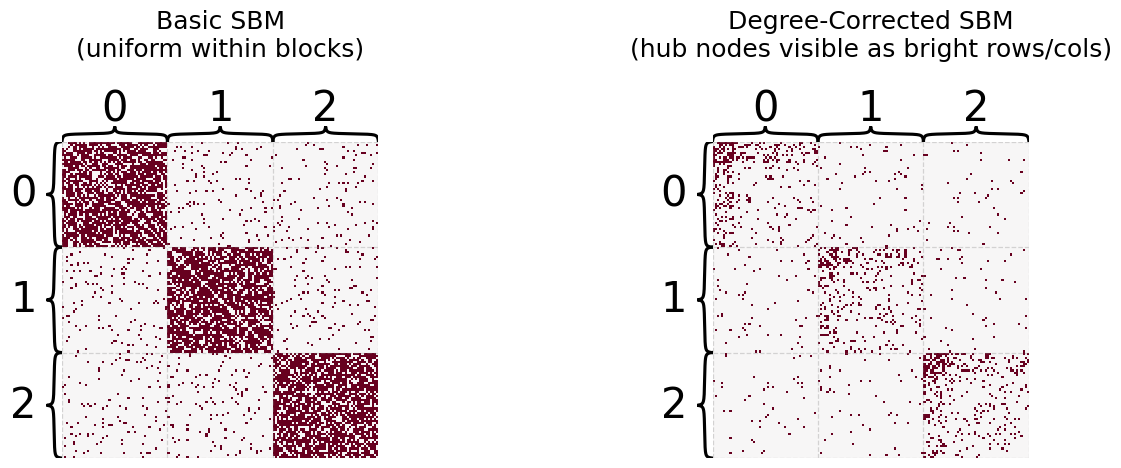

In [6]:
# Now let's generate a network that actually HAS degree heterogeneity
# We do this by creating a network where within each community,
# a few 'hub' nodes have much higher connectivity

# Create a network with 3 communities but varying degree structure
n_nodes = 150
n_per_block = 50

# Build probability matrix manually to create hub-like structure
P_dcsbm = np.zeros((n_nodes, n_nodes))

for block in range(3):
    start = block * n_per_block
    end = (block + 1) * n_per_block
    
    # Within block: first 10 nodes are hubs (high connectivity), rest are normal
    hub_nodes = range(start, start + 10)
    normal_nodes = range(start + 10, end)
    
    for i in range(start, end):
        for j in range(start, end):
            if i != j:
                theta_i = 0.8 if i in hub_nodes else 0.3
                theta_j = 0.8 if j in hub_nodes else 0.3
                P_dcsbm[i, j] = theta_i * theta_j * 0.9  # within block
    
    # Between blocks: low probability
    for other_block in range(3):
        if other_block != block:
            other_start = other_block * n_per_block
            other_end = (other_block + 1) * n_per_block
            for i in range(start, end):
                for j in range(other_start, other_end):
                    P_dcsbm[i, j] = 0.02

# Sample adjacency matrix from this probability matrix
A_dcsbm = (np.random.rand(n_nodes, n_nodes) < P_dcsbm).astype(int)
A_dcsbm = np.triu(A_dcsbm, 1)  # upper triangular (undirected)
A_dcsbm = A_dcsbm + A_dcsbm.T  # symmetrize

labels_dcsbm = np.repeat([0, 1, 2], n_per_block)

fig, axs = plt.subplots(1, 2, figsize=(14, 5))
heatmap(A_sbm, inner_hier_labels=labels_sbm, title='Basic SBM\n(uniform within blocks)', ax=axs[0], cbar=False)
heatmap(A_dcsbm, inner_hier_labels=labels_dcsbm, title='Degree-Corrected SBM\n(hub nodes visible as bright rows/cols)', ax=axs[1], cbar=False)
plt.tight_layout()
plt.show()

---
## 4. Mixed Membership SBM (MMSBM)

**Intuition:** In basic SBM, each node belongs to exactly ONE community. But in reality, people/nodes often belong to *multiple* communities simultaneously — a researcher might be in both a 'machine learning' and a 'neuroscience' community.

MMSBM gives each node a **membership vector** — a probability distribution over communities. A node with membership [0.8, 0.1, 0.1] mostly belongs to community 0, but partially to others.

$$P_{ij} = \pi_i^T B \pi_j$$

where $\pi_i$ is the membership vector of node $i$.

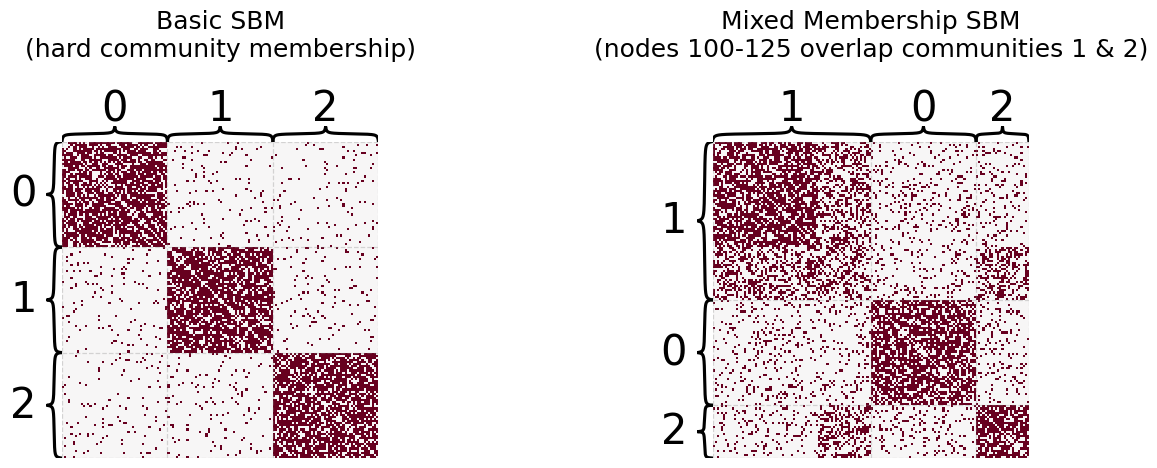

Notice: In MMSBM heatmap, the boundary between community 1 and 2 is FUZZY
This is because nodes 100-125 partially belong to BOTH communities


In [7]:
# Simulate Mixed Membership SBM manually
# Each node gets a membership vector (a distribution over communities)

n_nodes = 150
n_communities = 3

# Create membership vectors
# - First 50 nodes: mostly community 0 (pure members)
# - Next 50 nodes: mostly community 1 (pure members)
# - Last 50 nodes: mixed between community 1 and 2 (mixed members!)
memberships = np.zeros((n_nodes, n_communities))
memberships[:50] = [0.9, 0.05, 0.05]   # pure community 0
memberships[50:100] = [0.05, 0.9, 0.05]  # pure community 1
memberships[100:125] = [0.05, 0.5, 0.45]  # mixed community 1 & 2
memberships[125:150] = [0.05, 0.05, 0.9]  # pure community 2

# Block probability matrix
B_mm = np.array([
    [0.8, 0.05, 0.05],
    [0.05, 0.8, 0.05],
    [0.05, 0.05, 0.8],
])

# Compute probability matrix P = memberships @ B @ memberships.T
P_mm = memberships @ B_mm @ memberships.T

# Sample adjacency matrix
A_mm = (np.random.rand(n_nodes, n_nodes) < P_mm).astype(int)
A_mm = np.triu(A_mm, 1)
A_mm = A_mm + A_mm.T

# Labels: hard assignment based on dominant community
labels_mm = np.argmax(memberships, axis=1)

fig, axs = plt.subplots(1, 2, figsize=(14, 5))
heatmap(A_sbm, inner_hier_labels=labels_sbm, title='Basic SBM\n(hard community membership)', ax=axs[0], cbar=False)
heatmap(A_mm, inner_hier_labels=labels_mm, title='Mixed Membership SBM\n(nodes 100-125 overlap communities 1 & 2)', ax=axs[1], cbar=False)
plt.tight_layout()
plt.show()

print('Notice: In MMSBM heatmap, the boundary between community 1 and 2 is FUZZY')
print('This is because nodes 100-125 partially belong to BOTH communities')

---
## 5. Adjacency Spectral Embedding (ASE)

**Intuition:** Apply SVD to the adjacency matrix. Keep only the top `d` components. Each node gets a `d`-dimensional vector that captures its connectivity pattern.

$$X = U_d \Sigma_d^{1/2}$$

Nodes in the same community should cluster together in this space!

Embedding shape: (150, 3)


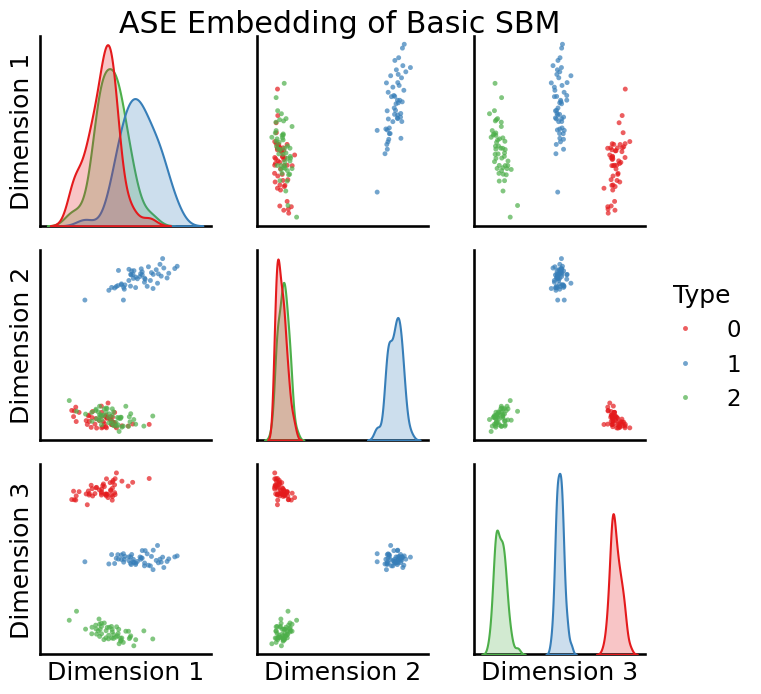

In [8]:
# Apply ASE to the basic SBM network
ase = AdjacencySpectralEmbed(n_components=3)
X_ase = ase.fit_transform(A_sbm)

# For undirected graphs, fit_transform returns just X (not a tuple)
print(f'Embedding shape: {X_ase.shape}')  # (150 nodes, 3 dimensions)

# Visualize the embedding — nodes should cluster by community!
pairplot(X_ase, labels=labels_sbm.astype(str), title='ASE Embedding of Basic SBM')
plt.show()

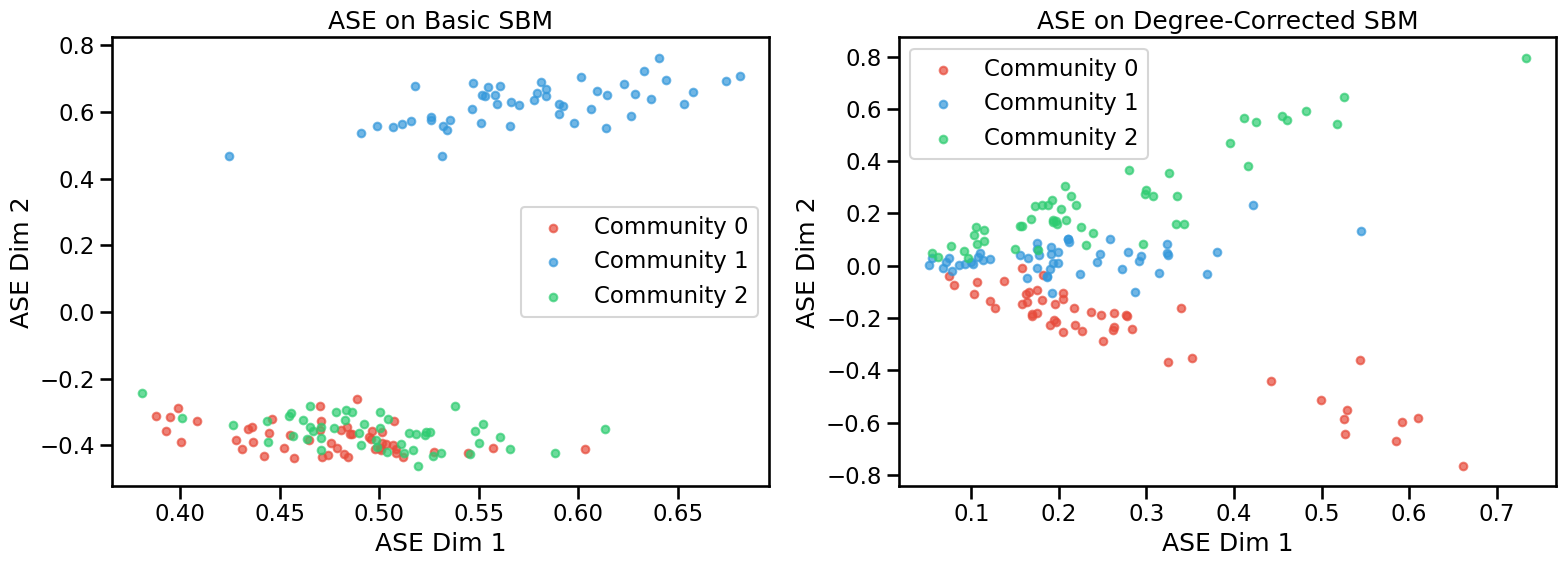

Notice: Communities should form clear clusters in embedding space!


In [9]:
# Apply ASE to the DCSBM network and compare
ase_dc = AdjacencySpectralEmbed(n_components=3)
X_ase_dc = ase_dc.fit_transform(pass_to_ranks(A_dcsbm))

fig, axs = plt.subplots(1, 2, figsize=(16, 6))

# Plot first 2 ASE dimensions for both
for i, (X, labels, title) in enumerate([
    (X_ase, labels_sbm, 'ASE on Basic SBM'),
    (X_ase_dc, labels_dcsbm, 'ASE on Degree-Corrected SBM')
]):
    colors = ['#e74c3c', '#3498db', '#2ecc71']
    for comm in range(3):
        mask = labels == comm
        axs[i].scatter(X[mask, 0], X[mask, 1], c=colors[comm], label=f'Community {comm}', alpha=0.7, s=30)
    axs[i].set_title(title)
    axs[i].set_xlabel('ASE Dim 1')
    axs[i].set_ylabel('ASE Dim 2')
    axs[i].legend()

plt.tight_layout()
plt.show()

print('Notice: Communities should form clear clusters in embedding space!')

---
## 6. Laplacian Spectral Embedding (LSE)

**Intuition:** Instead of SVD on the adjacency matrix, compute the Laplacian $L = D - A$ first, then do eigendecomposition on that. The Laplacian captures how different each node is from its neighbors, and its eigenvectors naturally reveal community structure.

LSE Embedding shape: (150, 3)


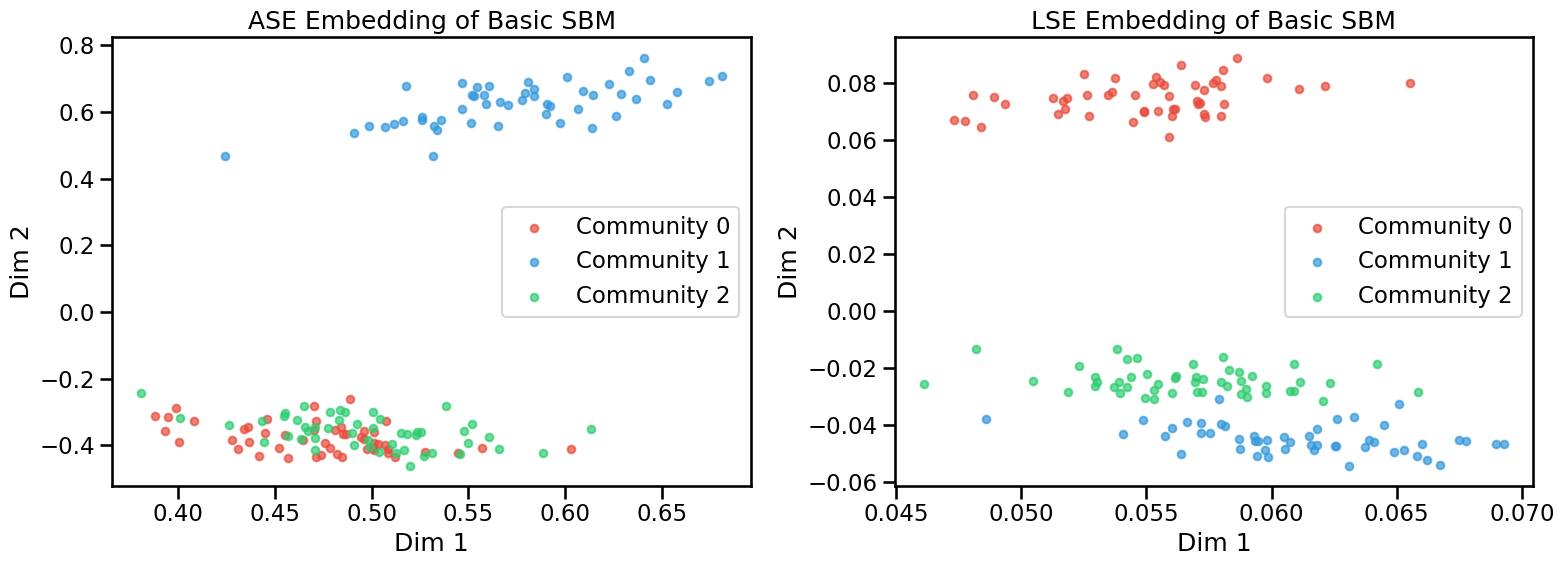

Both ASE and LSE should reveal community structure, but may capture different aspects!
Try on MMSBM to see which one better captures overlapping communities


In [10]:
# Apply LSE to the basic SBM network
lse = LaplacianSpectralEmbed(n_components=3, form='R-DAD')  # R-DAD = regularized version (recommended)
X_lse = lse.fit_transform(A_sbm)

print(f'LSE Embedding shape: {X_lse.shape}')

# Compare ASE vs LSE side by side
fig, axs = plt.subplots(1, 2, figsize=(16, 6))

colors = ['#e74c3c', '#3498db', '#2ecc71']

for i, (X, title) in enumerate([(X_ase, 'ASE Embedding'), (X_lse, 'LSE Embedding')]):
    for comm in range(3):
        mask = labels_sbm == comm
        axs[i].scatter(X[mask, 0], X[mask, 1], c=colors[comm], label=f'Community {comm}', alpha=0.7, s=30)
    axs[i].set_title(f'{title} of Basic SBM')
    axs[i].set_xlabel('Dim 1')
    axs[i].set_ylabel('Dim 2')
    axs[i].legend()

plt.tight_layout()
plt.show()

print('Both ASE and LSE should reveal community structure, but may capture different aspects!')
print('Try on MMSBM to see which one better captures overlapping communities')

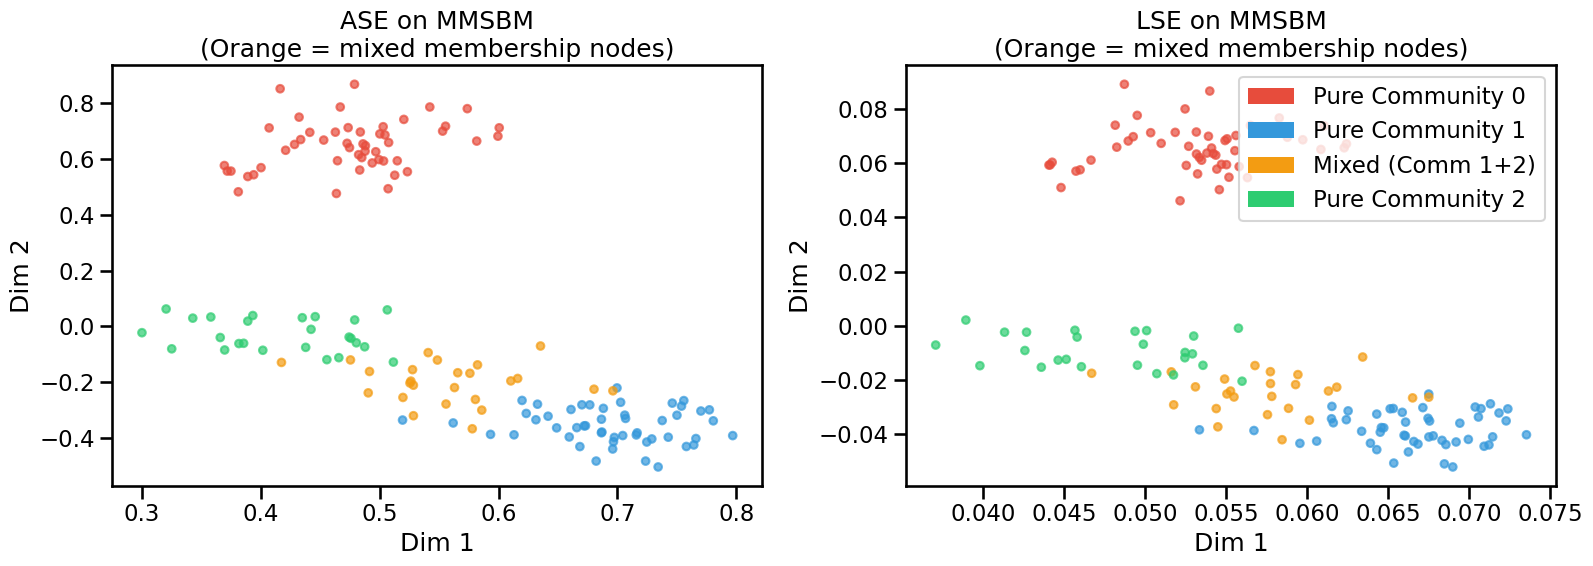

Key question: Do the orange (mixed) nodes sit BETWEEN the blue and green clusters?
If yes, the embedding is capturing the mixed membership structure!


In [11]:
# Apply both on MMSBM — which one better handles overlapping memberships?
ase_mm = AdjacencySpectralEmbed(n_components=3)
X_ase_mm = ase_mm.fit_transform(A_mm)

lse_mm = LaplacianSpectralEmbed(n_components=3, form='R-DAD')
X_lse_mm = lse_mm.fit_transform(A_mm)

fig, axs = plt.subplots(1, 2, figsize=(16, 6))

# Color: pure community 0 = red, pure community 1 = blue, mixed = orange, pure community 2 = green
node_colors_mm = []
for i in range(n_nodes):
    if i < 50: node_colors_mm.append('#e74c3c')       # pure comm 0 — red
    elif i < 100: node_colors_mm.append('#3498db')    # pure comm 1 — blue
    elif i < 125: node_colors_mm.append('#f39c12')    # MIXED comm 1+2 — orange
    else: node_colors_mm.append('#2ecc71')            # pure comm 2 — green

for i, (X, title) in enumerate([(X_ase_mm, 'ASE on MMSBM'), (X_lse_mm, 'LSE on MMSBM')]):
    axs[i].scatter(X[:, 0], X[:, 1], c=node_colors_mm, alpha=0.7, s=30)
    axs[i].set_title(f'{title}\n(Orange = mixed membership nodes)')
    axs[i].set_xlabel('Dim 1')
    axs[i].set_ylabel('Dim 2')

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#e74c3c', label='Pure Community 0'),
    Patch(facecolor='#3498db', label='Pure Community 1'),
    Patch(facecolor='#f39c12', label='Mixed (Comm 1+2)'),
    Patch(facecolor='#2ecc71', label='Pure Community 2'),
]
axs[1].legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.show()

print('Key question: Do the orange (mixed) nodes sit BETWEEN the blue and green clusters?')
print('If yes, the embedding is capturing the mixed membership structure!')

---
## 7. Node2Vec

**Intuition:** Generate random walks on the network (like random sentences), then train a Word2Vec model to predict context nodes. The learned weights = node embeddings. Nodes that appear in similar walk contexts get similar vectors.

Key parameters:
- `num_walks` — how many random walks to generate per node
- `walk_length` — how long each walk is
- `inout_hyperparameter (q)` — controls exploration (high q = local, low q = global)
- `return_hyperparameter (p)` — controls how likely you are to return to previous node

In [12]:
# Convert adjacency matrix to networkx graph for Node2Vec
G_sbm = nx.from_numpy_array(A_sbm)

# Run Node2Vec
node2vec_emb, node_ids = node2vec_embed(
    G_sbm,
    dimensions=16,       # embedding dimension
    num_walks=10,        # walks per node
    walk_length=20,      # length of each walk
    inout_hyperparameter=1.0,   # q: balance local vs global
    return_hyperparameter=1.0,  # p: return probability
    random_seed=42
)

print(f'Node2Vec embedding shape: {node2vec_emb.shape}')  # (150 nodes, 16 dimensions)

# Reorder labels to match node_ids ordering
labels_n2v = np.array([labels_sbm[node_id] for node_id in node_ids])

Node2Vec embedding shape: (150, 16)


c:\Users\ADMIN\AppData\Local\Programs\Python\Python39\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


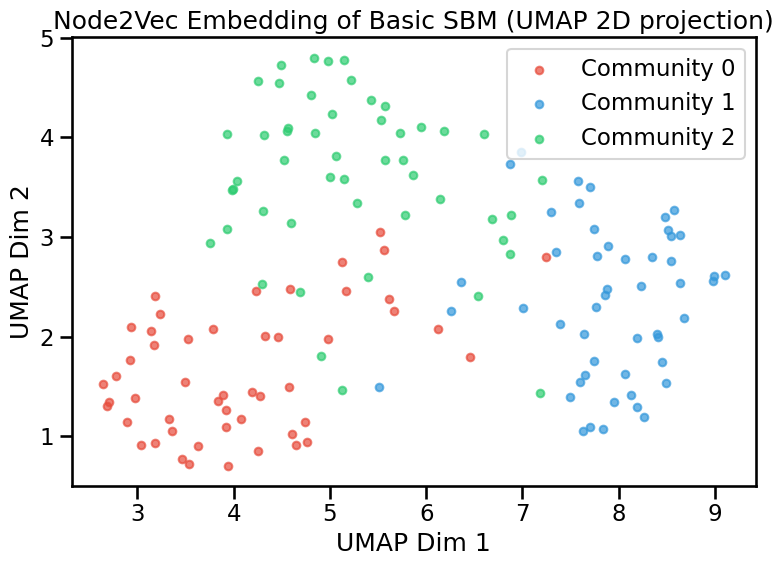

In [13]:
# Node2Vec gives 16 dimensions — use UMAP to reduce to 2D for visualization
umapper = UMAP(n_components=2, metric='cosine', random_state=42)
X_n2v_2d = umapper.fit_transform(node2vec_emb)

# Plot
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
colors = ['#e74c3c', '#3498db', '#2ecc71']
for comm in range(3):
    mask = labels_n2v == comm
    ax.scatter(X_n2v_2d[mask, 0], X_n2v_2d[mask, 1], c=colors[comm], label=f'Community {comm}', alpha=0.7, s=30)
ax.set_title('Node2Vec Embedding of Basic SBM (UMAP 2D projection)')
ax.set_xlabel('UMAP Dim 1')
ax.set_ylabel('UMAP Dim 2')
ax.legend()
plt.tight_layout()
plt.show()

c:\Users\ADMIN\AppData\Local\Programs\Python\Python39\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\ADMIN\AppData\Local\Programs\Python\Python39\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\ADMIN\AppData\Local\Programs\Python\Python39\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


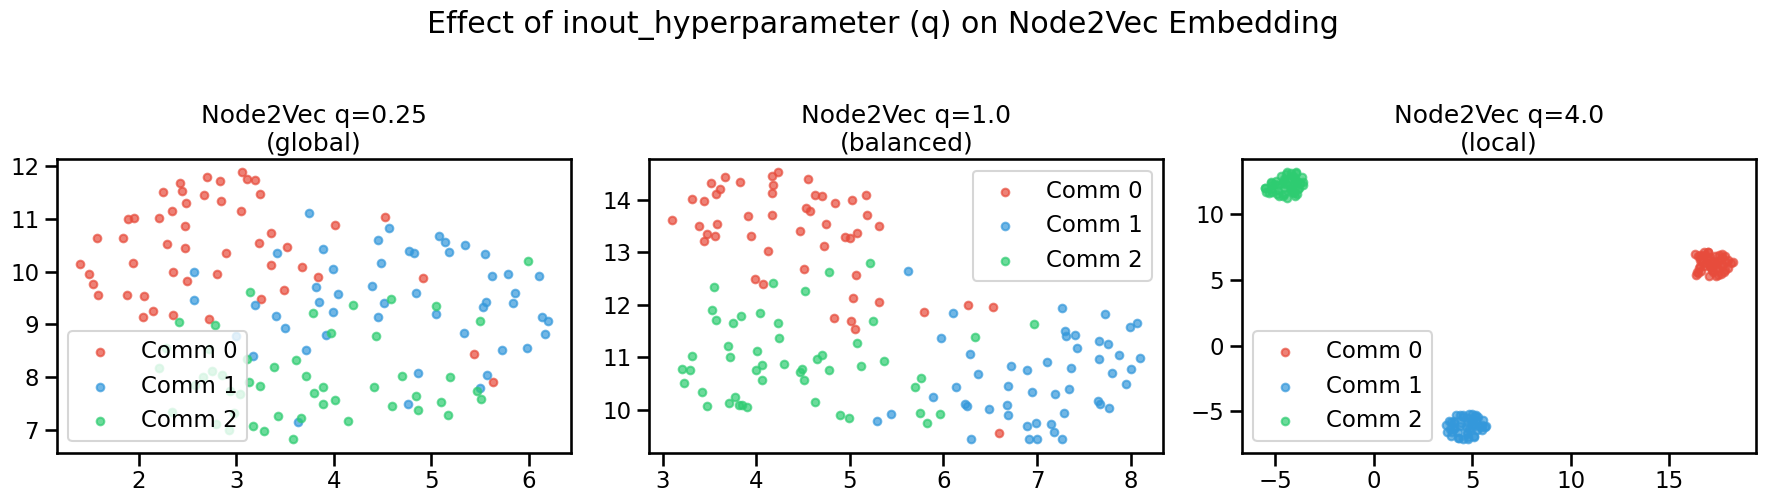

In [14]:
# Experiment: How does changing q (inout_hyperparameter) affect the embedding?
# Low q = explores far (global structure) | High q = stays local (community structure)

fig, axs = plt.subplots(1, 3, figsize=(18, 5))

for i, q in enumerate([0.25, 1.0, 4.0]):
    emb, ids = node2vec_embed(
        G_sbm, dimensions=16, num_walks=10, walk_length=20,
        inout_hyperparameter=q, return_hyperparameter=1.0, random_seed=42
    )
    emb_2d = UMAP(n_components=2, metric='cosine', random_state=42).fit_transform(emb)
    labs = np.array([labels_sbm[nid] for nid in ids])
    
    for comm in range(3):
        mask = labs == comm
        axs[i].scatter(emb_2d[mask, 0], emb_2d[mask, 1], c=colors[comm], label=f'Comm {comm}', alpha=0.7, s=30)
    axs[i].set_title(f'Node2Vec q={q}\n({"global" if q < 1 else "local" if q > 1 else "balanced"})')
    axs[i].legend()

plt.suptitle('Effect of inout_hyperparameter (q) on Node2Vec Embedding', y=1.02)
plt.tight_layout()
plt.show()

---
## 8. Compare All Embeddings Side by Side

Final comparison: ASE vs LSE vs Node2Vec on the same SBM network.

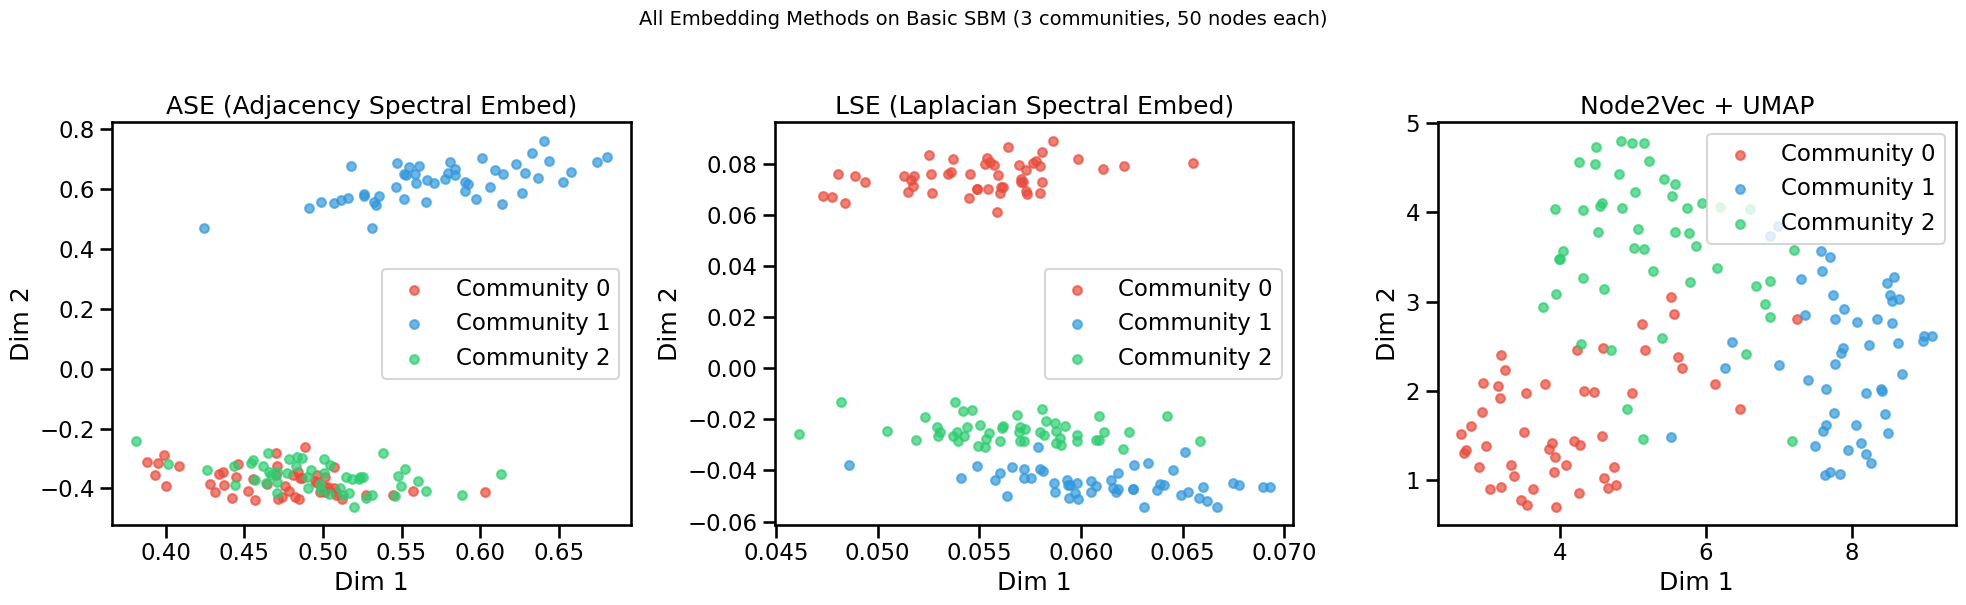

All three methods should show 3 clear clusters!
But they may look different because they capture different aspects of the network


In [15]:
# Reduce ASE and LSE to 2D for fair comparison with Node2Vec

# ASE: take first 2 dimensions directly
X_ase_2d = X_ase[:, :2]

# LSE: take first 2 dimensions directly
X_lse_2d = X_lse[:, :2]

# Node2Vec: already computed above as X_n2v_2d (UMAP projected)

fig, axs = plt.subplots(1, 3, figsize=(20, 6))

titles = ['ASE (Adjacency Spectral Embed)', 'LSE (Laplacian Spectral Embed)', 'Node2Vec + UMAP']
embeddings = [X_ase_2d, X_lse_2d, X_n2v_2d]
all_labels = [labels_sbm, labels_sbm, labels_n2v]

for i, (X, labs, title) in enumerate(zip(embeddings, all_labels, titles)):
    for comm in range(3):
        mask = labs == comm
        axs[i].scatter(X[mask, 0], X[mask, 1], c=colors[comm], label=f'Community {comm}', alpha=0.7, s=40)
    axs[i].set_title(title)
    axs[i].set_xlabel('Dim 1')
    axs[i].set_ylabel('Dim 2')
    axs[i].legend()

plt.suptitle('All Embedding Methods on Basic SBM (3 communities, 50 nodes each)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print('All three methods should show 3 clear clusters!')
print('But they may look different because they capture different aspects of the network')

c:\Users\ADMIN\AppData\Local\Programs\Python\Python39\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


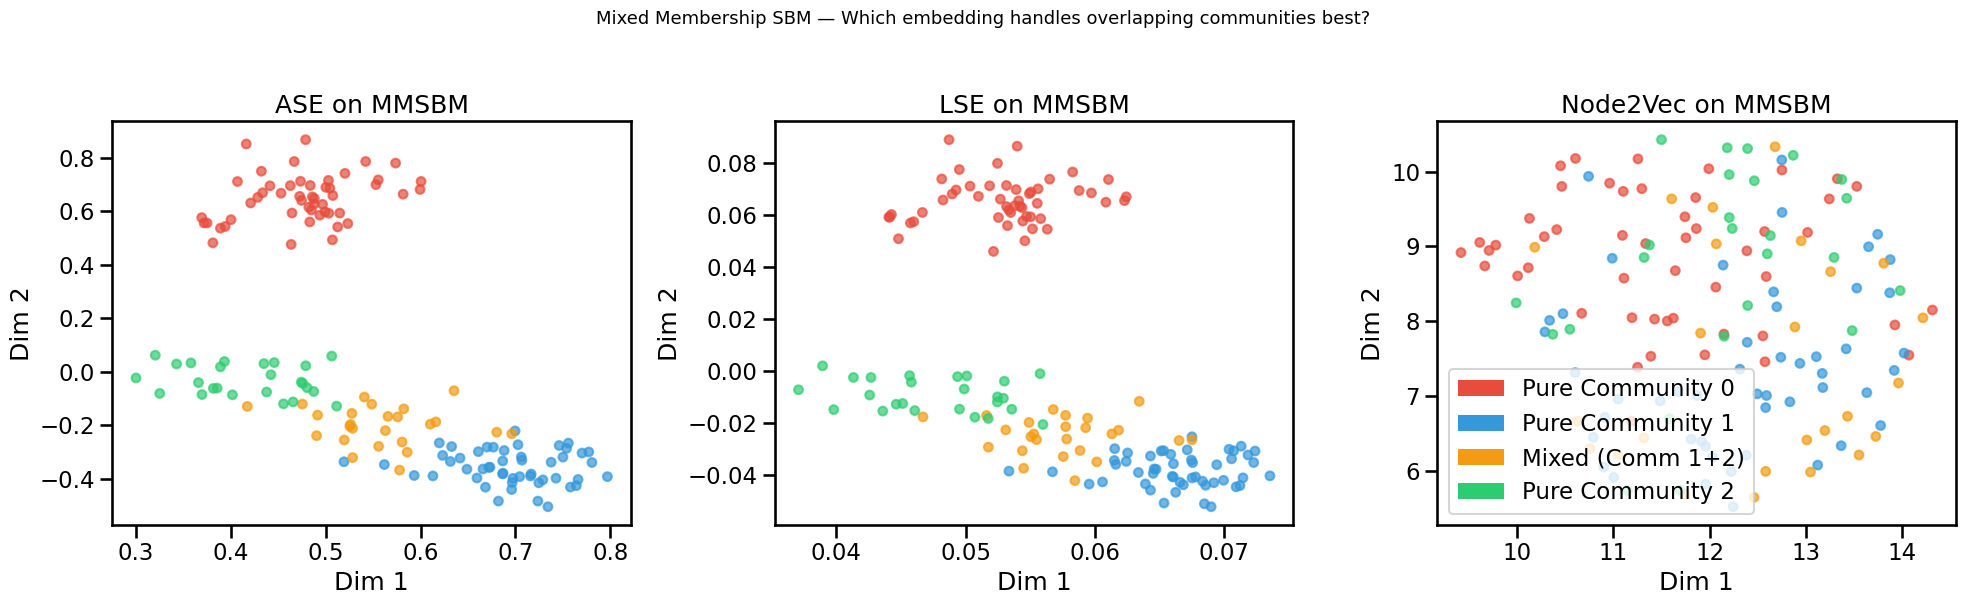

Key observation: Do orange nodes sit BETWEEN blue and green?
This would mean the embedding successfully captured the mixed membership!


In [16]:
# BONUS: Apply all embeddings to the MMSBM and see which one
# best places the mixed-membership nodes (orange) between communities

G_mm = nx.from_numpy_array(A_mm)
n2v_mm_emb, n2v_mm_ids = node2vec_embed(
    G_mm, dimensions=16, num_walks=10, walk_length=20,
    inout_hyperparameter=1.0, return_hyperparameter=1.0, random_seed=42
)
X_n2v_mm_2d = UMAP(n_components=2, metric='cosine', random_state=42).fit_transform(n2v_mm_emb)

fig, axs = plt.subplots(1, 3, figsize=(20, 6))

# Use the color scheme from before: red=pure0, blue=pure1, orange=mixed, green=pure2
n2v_mm_colors = [node_colors_mm[nid] for nid in n2v_mm_ids]

embs_mm = [X_ase_mm[:, :2], X_lse_mm[:, :2], X_n2v_mm_2d]
cols_mm = [node_colors_mm, node_colors_mm, n2v_mm_colors]
titles_mm = ['ASE on MMSBM', 'LSE on MMSBM', 'Node2Vec on MMSBM']

for i, (X, col, title) in enumerate(zip(embs_mm, cols_mm, titles_mm)):
    axs[i].scatter(X[:, 0], X[:, 1], c=col, alpha=0.7, s=40)
    axs[i].set_title(title)
    axs[i].set_xlabel('Dim 1')
    axs[i].set_ylabel('Dim 2')

legend_elements = [
    Patch(facecolor='#e74c3c', label='Pure Community 0'),
    Patch(facecolor='#3498db', label='Pure Community 1'),
    Patch(facecolor='#f39c12', label='Mixed (Comm 1+2)'),
    Patch(facecolor='#2ecc71', label='Pure Community 2'),
]
axs[2].legend(handles=legend_elements)

plt.suptitle('Mixed Membership SBM — Which embedding handles overlapping communities best?', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print('Key observation: Do orange nodes sit BETWEEN blue and green?')
print('This would mean the embedding successfully captured the mixed membership!')

---
## Summary

| Model | Key Idea | Best For |
|---|---|---|
| **Basic SBM** | Hard community membership, uniform within-block prob | Clean community structure |
| **DCSBM** | SBM + per-node degree (hub nodes) | Real networks with degree variation |
| **MMSBM** | Nodes can belong to multiple communities | Overlapping communities |

| Embedding | Key Idea | Best For |
|---|---|---|
| **ASE** | SVD on adjacency matrix | RDPG-like networks, connectivity patterns |
| **LSE** | Eigendecomp on Laplacian | Community/cut structure |
| **Node2Vec** | Random walks + Word2Vec | Large networks, flexible structure |

**Next steps:** Try these on real-world data (Cora dataset from the tutorial)!